# Introduction to PyBullet

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/LxViRaL-teaching/medical-robotics-2026/blob/main/week-1/pybullet_intro.ipynb)

This notebook is your first contact with **PyBullet**, the physics simulator we'll use in most labs. It isn't part of any graded lab, the goal is just to build confidence with the basics (connecting to the simulator, loading a robot from a **URDF**, driving its joints, stepping the simulation) before you use them for real from Lab 2 onward.

**Recommended way: locally**, where the simulation opens a 3D window (`p.GUI`) and you see everything happen in real time. On Google Colab (button above, plan B if you can't install locally) there's no screen, so the next cell detects that and uses `p.DIRECT` automatically. The simulation still runs, just without a window, and the results in the plots are the same.

In [1]:
import sys, subprocess

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "pybullet"], check=True)
    print("Running on Google Colab (no 3D window). You will have to load the .urdf manually with: from google.colab import files; files.upload()")
else: 
    print("Running locally (3D window should open with p.GUI)")

Running locally (3D window should open with p.GUI)


In [2]:
import time
import numpy as np
import matplotlib.pyplot as plt
import pybullet as p
import pybullet_data

pybullet build time: Oct 21 2025 11:20:22


## 1. Connect to the simulator

Everything in PyBullet starts with `p.connect(...)`, which connects to a **physics client**, the process that does the simulation's calculations. There are two main modes:

- `p.GUI`: opens a 3D window where you see the simulation in real time. Only works with a screen (locally).
- `p.DIRECT`: runs the simulation with no window at all, faster, works anywhere (including Colab). This is what your scripts/notebooks will use whenever you only need the numbers (positions, angles, forces) and not the visualization.

`pybullet_data` ships with a few ready-to-use models (a ground plane, some simple shapes, and demo robots), handy for experimenting without having to write a URDF from scratch.

In [4]:
client = p.connect(p.DIRECT if IN_COLAB else p.GUI)
p.setAdditionalSearchPath(pybullet_data.getDataPath())
p.setGravity(0, 0, -9.8, physicsClientId=client)
print("Connected. Physics client ID:", client)

error: Only one local in-process GUI/GUI_SERVER connection allowed. Use DIRECT connection mode or start a separate GUI physics server (ExampleBrowser, App_SharedMemoryPhysics_GUI, App_SharedMemoryPhysics_VR) and connect over SHARED_MEMORY, UDP or TCP instead.

If you're using `p.GUI`, you should have noticed that a visualization window has opened.

## 2. Load the ground plane and a pendulum

`p.loadURDF(...)` loads a model from a **URDF** file (the format that describes a robot's geometry, mass, and joints, explained right below). Each call returns a **body ID**, which we use afterward to refer to that specific object.

`pendulum.urdf`, in this same folder, is a simple motorized pendulum: a fixed base, a body, and an arm with a ball at the tip, connected by a single motor.

In [4]:
plane_id = p.loadURDF("plane.urdf", physicsClientId=client)
pendulum_id = p.loadURDF("pendulum.urdf", basePosition=[0, 0, 0], useFixedBase=True, physicsClientId=client)

print("ground plane: body ID", plane_id)
print("pendulum: body ID", pendulum_id)

ground plane: body ID 0
pendulum: body ID 1


## 3. URDF: what's inside

A URDF describes a robot as a tree of:

- **`<link>`**: a rigid body (a piece of the robot). It can have three blocks:
  - `<visual>`: the geometry used to draw the link (what you see in the `p.GUI` window).
  - `<collision>`: the geometry used to compute collisions (often simpler than the visual one, since it's faster to compute with).
  - `<inertial>`: mass and moments of inertia. **Without this, the link is treated as effectively weightless.** A common mistake is forgetting the `<inertial>` block and having the robot behave strangely in simulation.
- **`<joint>`**: connects two links (`parent` and `child`) and says how one can move relative to the other. The most common types:
  - `fixed`: rigid, doesn't move (used to weld geometric pieces together).
  - `revolute`: rotates around an axis, with limits (`lower`/`upper`).
  - `continuous`: like `revolute`, but with no limits (can spin all the way around).
  - `prismatic`: slides along an axis instead of rotating (e.g. a gripper's fingers).

`p.getNumJoints(...)` and `p.getJointInfo(...)` let you inspect a robot's structure once it's loaded. Note that PyBullet reports `continuous` joints as `revolute` (it doesn't distinguish the two in the returned type), recognizable instead by having no limits (`lower > upper`).

Let's write two small helper functions and use them on the pendulum we just loaded: one to list its joints, one to list its links.

In [32]:
JOINT_TYPES = {
    p.JOINT_REVOLUTE: "revolute",
    p.JOINT_PRISMATIC: "prismatic",
    p.JOINT_SPHERICAL: "spherical",
    p.JOINT_PLANAR: "planar",
    p.JOINT_FIXED: "fixed",
}

def joint_summary(body_id, name="Robot"):
    n = p.getNumJoints(body_id, physicsClientId=client)
    print(f"{name}: {n} joints")
    for j in range(n):
        info = p.getJointInfo(body_id, j, physicsClientId=client)
        joint_name = info[1].decode()
        joint_type = JOINT_TYPES.get(info[2], info[2])
        print(f"  [{j}] {joint_name:<28s} {joint_type}")

def link_summary(body_id, name="Robot"):
    base_name, _ = p.getBodyInfo(body_id, physicsClientId=client)
    print(f"{name}: links")
    print(f"  [base] {base_name.decode()}")
    for j in range(p.getNumJoints(body_id, physicsClientId=client)):
        info = p.getJointInfo(body_id, j, physicsClientId=client)
        print(f"  [{j}] {info[12].decode()}")

In [6]:
joint_summary(pendulum_id, "Pendulum")
link_summary(pendulum_id, "Pendulum")

Pendulum: 4 joints
  [0] first_joint                  fixed
  [1] motor_joint                  revolute
  [2] arm_joint                    fixed
  [3] arm_joint2                   fixed
Pendulum: links
  [base] base_link
  [0] body_link
  [1] motor_link
  [2] arm_link
  [3] ball_link


## 4. Command a torque

Every joint has a name, and the one we care about here is `motor_joint`, the only one that isn't `fixed`. Let's find it by name (never assume it's a particular index) and apply a constant torque to it with `p.TORQUE_CONTROL`.

Run the cell below and look at what happens to the pendulum (in `p.GUI`, watch the window; either way, look at the plots that follow). It should wobble, not swing over the top, not sit still.

_One thing to watch out for: by default, every joint in PyBullet is held by an internal velocity motor with target 0, which acts like a brake. If you skip this step, applying a torque won't seem to do much. We turn it off first by setting that motor's force to 0._

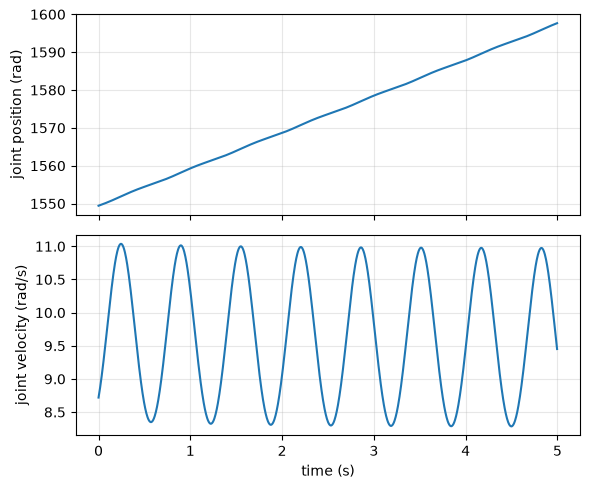

In [28]:
motor_joint = next(
    j for j in range(p.getNumJoints(pendulum_id, physicsClientId=client))
    if p.getJointInfo(pendulum_id, j, physicsClientId=client)[1] == b"motor_joint"
)

p.setJointMotorControl2(pendulum_id, motor_joint, controlMode=p.VELOCITY_CONTROL, force=0, physicsClientId=client)

dt = 1.0 / 240.0
duration = 5.0
torque = 5.0

t_hist, pos_hist, vel_hist = [], [], []
for i in range(int(duration / dt)):
    p.setJointMotorControl2(pendulum_id, motor_joint, controlMode=p.TORQUE_CONTROL, force=torque, physicsClientId=client)
    p.stepSimulation(physicsClientId=client)
    joint_pos, joint_vel, _, _ = p.getJointState(pendulum_id, motor_joint, physicsClientId=client)
    t_hist.append(i * dt)
    pos_hist.append(joint_pos)
    vel_hist.append(joint_vel)
    time.sleep(dt)

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(6, 5))
ax1.plot(t_hist, pos_hist)
ax1.set_ylabel("joint position (rad)")
ax1.grid(alpha=0.3)
ax2.plot(t_hist, vel_hist)
ax2.set_xlabel("time (s)")
ax2.set_ylabel("joint velocity (rad/s)")
ax2.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Why does it wobble instead of just rising and staying there? A constant torque isn't a controller: nothing is checking where the pendulum is and correcting for it. Gravity pulls it back down, the torque pushes it back up, and with a bit of damping in the joint it settles into a swing instead of either sitting still or spinning forever. Later in the course you'll come back to this exact pendulum to design a real feedback controller for it, one that reads the joint's position and decides the torque itself, instead of a constant value you pick in advance.

## 5. Load a second robot: R2D2

`pybullet_data` also ships a demo robot called R2D2. Let's load it above the ground and let it fall, the same way we'll load real robots for the rest of the labs.

In [59]:
robot_r2d2_id = p.loadURDF("r2d2.urdf", basePosition=[3, 0, 1.5], physicsClientId=client)

print("R2D2: body ID", robot_r2d2_id)

R2D2: body ID 16


## 6. Query the state

`p.getBasePositionAndOrientation(...)` returns the position (x, y, z) and orientation (as a [quaternion](https://en.wikipedia.org/wiki/Quaternion)) of an object's base body. We loaded the R2D2 at a height of 1.5 m. Let's confirm that, then see what happens once the simulation steps forward (it should fall, since we set gravity pointing down in step 1).

In [60]:
pos, orn = p.getBasePositionAndOrientation(robot_r2d2_id, physicsClientId=client)
print("position (x, y, z):", pos)
print("orientation (quaternion):", orn)

position (x, y, z): (3.0, 0.0, 1.5)
orientation (quaternion): (0.0, 0.0, 0.0, 1.0)


## 7. Step the simulation

`p.stepSimulation()` advances the physics by a small time interval (1/240 second by default). Nothing moves on its own, you have to call this repeatedly, in a loop, to see the effect of gravity, applied forces, etc. This is the same loop we used for the pendulum above, just watching the base position instead of a joint. Let's step the simulation for 2 seconds and record the R2D2's height over time, to confirm it falls and lands on the ground.

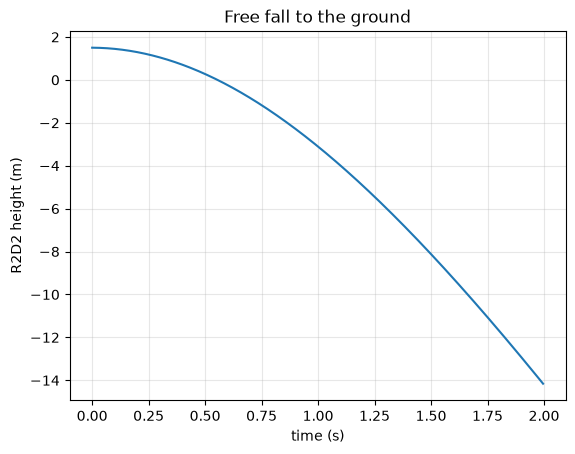

In [61]:
dt = 1.0 / 240.0
duration = 2.0

t_hist, z_hist = [], []
for i in range(int(duration / dt)):
    p.stepSimulation(physicsClientId=client)
    pos, _ = p.getBasePositionAndOrientation(robot_r2d2_id, physicsClientId=client)
    t_hist.append(i * dt)
    z_hist.append(pos[2])

plt.plot(t_hist, z_hist)
plt.xlabel("time (s)")
plt.ylabel("R2D2 height (m)")
plt.title("Free fall to the ground")
plt.grid(alpha=0.3)
plt.show()

## 8. Initial velocity, and simulation time vs. real time

`p.resetBaseVelocity(...)` gives an object an instantaneous linear velocity. Let's restart the R2D2 and give it a horizontal velocity, so you see projectile motion (a parabola) instead of a vertical drop.

Before running it: the cell below times itself with `time.perf_counter()` and prints how long it actually took, next to `duration`, the amount of simulated time it covers. Do you think those two numbers will be close? Run it and check.

simulated time: 1.00 s
wall clock time: 1.39 s


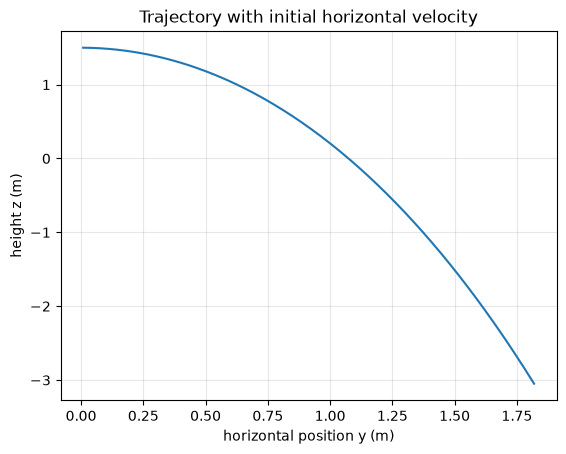

In [31]:
p.resetBasePositionAndOrientation(robot_r2d2_id, [3, 0, 1.5], [0, 0, 0, 1], physicsClientId=client)
p.resetBaseVelocity(robot_r2d2_id, linearVelocity=[0.0, 2.0, 0.0], physicsClientId=client)

wall_start = time.perf_counter()
y_hist, z_hist2 = [], []
for i in range(int(duration / dt)):
    p.stepSimulation(physicsClientId=client)
    pos, _ = p.getBasePositionAndOrientation(robot_r2d2_id, physicsClientId=client)
    y_hist.append(pos[1])
    z_hist2.append(pos[2])
    time.sleep(dt)
wall_elapsed = time.perf_counter() - wall_start

print(f"simulated time: {duration:.2f} s")
print(f"wall clock time: {wall_elapsed:.2f} s")

plt.plot(y_hist, z_hist2)
plt.xlabel("horizontal position y (m)")
plt.ylabel("height z (m)")
plt.title("Trajectory with initial horizontal velocity")
plt.grid(alpha=0.3)
plt.show()

The two numbers probably weren't close at all: `stepSimulation()` just does the math for one time step, it doesn't wait around, so the loop finishes as fast as your computer can compute it, usually much faster than `duration` seconds.

Now uncomment the `# time.sleep(dt)` line in the cell above and run it again. What happens to the wall clock time this time? And if it's still not exactly matching `duration`, why do you think that is? (Hint: There are two main reasons.)

## 9. Two more control modes: velocity and position

We drove the pendulum's motor with `p.TORQUE_CONTROL`. PyBullet has two other control modes worth knowing: `p.VELOCITY_CONTROL` (target a speed, useful for wheels) and `p.POSITION_CONTROL` (target an angle or position, PyBullet handles reaching it for you). Let's list R2D2's joints again and try both.

In [33]:
joint_summary(robot_r2d2_id, "R2D2")

R2D2: 15 joints
  [0] base_to_right_leg            fixed
  [1] right_base_joint             fixed
  [2] right_front_wheel_joint      revolute
  [3] right_back_wheel_joint       revolute
  [4] base_to_left_leg             fixed
  [5] left_base_joint              fixed
  [6] left_front_wheel_joint       revolute
  [7] left_back_wheel_joint        revolute
  [8] gripper_extension            prismatic
  [9] left_gripper_joint           revolute
  [10] left_tip_joint               fixed
  [11] right_gripper_joint          revolute
  [12] right_tip_joint              fixed
  [13] head_swivel                  revolute
  [14] tobox                        fixed


### 9.1 Velocity control: the wheels

Instead of hard coding indices, let's build a dictionary of R2D2's wheel joints by searching their names, then command all of them with `p.VELOCITY_CONTROL`.

In [56]:


WHEEL_JOINTS = {}
for j in range(p.getNumJoints(robot_r2d2_id, physicsClientId=client)):
    info = p.getJointInfo(robot_r2d2_id, j, physicsClientId=client)
    joint_name = info[1].decode()
    if "wheel" in joint_name:
        WHEEL_JOINTS[joint_name] = j

print(WHEEL_JOINTS)

for joint_name, j in WHEEL_JOINTS.items():
    p.setJointMotorControl2(robot_r2d2_id, j, controlMode=p.VELOCITY_CONTROL, targetVelocity=4.0, force=5.0, physicsClientId=client)

for i in range(int(2.0 / dt)):
    p.stepSimulation(physicsClientId=client)
    time.sleep(dt)

pos, _ = p.getBasePositionAndOrientation(robot_r2d2_id, physicsClientId=client)
print("R2D2 position after driving the wheels for 2 s:", pos)

{'right_front_wheel_joint': 2, 'right_back_wheel_joint': 3, 'left_front_wheel_joint': 6, 'left_back_wheel_joint': 7}
R2D2 position after driving the wheels for 2 s: (2.9999999990089252, 0.00028626282649942426, -3.0739150089032496)


The R2D2 should have rolled across the ground. Notice we never told it *where* to go, only how fast each wheel should spin. Everything else (rolling, friction with the ground, the resulting motion) came out of the physics.

> ### Exercise: 
> | Can you make the robot spin? | 
> | :--- |


### 9.2 Position control: the gripper arm

R2D2 also has a small gripper: `gripper_extension` (a `prismatic` joint that slides the arm out) and `left_gripper_joint` (a `revolute` joint that closes the fingers). Let's command both with `p.POSITION_CONTROL` and watch it extend and close.

In [46]:
for joint_name, j in WHEEL_JOINTS.items():
    p.setJointMotorControl2(robot_r2d2_id, j, controlMode=p.VELOCITY_CONTROL, targetVelocity=0.0, force=5.0, physicsClientId=client)

gripper_joints = {}
for j in range(p.getNumJoints(robot_r2d2_id, physicsClientId=client)):
    info = p.getJointInfo(robot_r2d2_id, j, physicsClientId=client)
    joint_name = info[1].decode()
    if joint_name in ("gripper_extension", "left_gripper_joint", "right_gripper_joint"):
        gripper_joints[joint_name] = j


p.setJointMotorControl2(robot_r2d2_id, gripper_joints["gripper_extension"], controlMode=p.POSITION_CONTROL, targetPosition=-0.05, force=20, physicsClientId=client)
p.setJointMotorControl2(robot_r2d2_id, gripper_joints["left_gripper_joint"], controlMode=p.POSITION_CONTROL, targetPosition=0.0, force=20, physicsClientId=client)
p.setJointMotorControl2(robot_r2d2_id, gripper_joints["right_gripper_joint"], controlMode=p.POSITION_CONTROL, targetPosition=0.0, force=20, physicsClientId=client)

for i in range(int(2.0 / dt)):
    p.stepSimulation(physicsClientId=client)

for joint_name, j in gripper_joints.items():
    joint_pos, _, _, _ = p.getJointState(robot_r2d2_id, j, physicsClientId=client)
    print(f"{joint_name}: reached {joint_pos:.3f}")

gripper_extension: reached -0.050
left_gripper_joint: reached -0.000
right_gripper_joint: reached -0.000


Both joints should have reached almost exactly the position you asked for. That's the difference from `p.TORQUE_CONTROL`: with position control, PyBullet runs its own controller in the background so you can just say where you want the joint to end up.

## 10. A full arm: Franka Panda

PyBullet includes the URDF for the **Franka Emika Panda** (`franka_panda/panda.urdf`), a 7-degree-of-freedom arm with a gripper you'll encounter later in the course. We load it with `useFixedBase=True`, because a manipulator arm is bolted to a table or base, it wouldn't make sense for it to fall under gravity like the R2D2.

In [15]:
panda_id = p.loadURDF("franka_panda/panda.urdf", basePosition=[-3, 0, 0], useFixedBase=True, physicsClientId=client)
joint_summary(panda_id, "Franka Panda")

Franka Panda: 12 joints
  [0] panda_joint1                 revolute
  [1] panda_joint2                 revolute
  [2] panda_joint3                 revolute
  [3] panda_joint4                 revolute
  [4] panda_joint5                 revolute
  [5] panda_joint6                 revolute
  [6] panda_joint7                 revolute
  [7] panda_joint8                 fixed
  [8] panda_hand_joint             fixed
  [9] panda_finger_joint1          prismatic
  [10] panda_finger_joint2          prismatic
  [11] panda_grasptarget_hand       fixed


> ### Exercise: where does the gripper end up?
>  Set: 
> - `panda_joint2` to 90º, 
> - `panda_joint3` to 180º,  and 
> - `panda_joint4` to -45º 
> (check the printed joint list above: `panda_joint4`'s limits only go negative, that's the elbow, and elbows only bend one way). 
> 
> Use `p.resetJointState(...)` for each.
> 
> | Then use `p.getLinkState(panda_id, 11, computeForwardKinematics=True)` to read the position of `panda_grasptarget`, the link that marks where the gripper actually is.  |
> | :--- |



In [16]:
import math


# TODO: set panda_joint2 to 90 degrees with p.resetJointState(...)
# TODO: set panda_joint3 to 180 degrees with p.resetJointState(...)
# TODO: set panda_joint4 to -45 degrees with p.resetJointState(...)

# TODO: read panda_grasptarget's position with p.getLinkState(panda_id, idx, computeForwardKinematics=True) and print it

In the next class, we will answer these questions: given a set of joint angles, where does the end of the arm end up? What about the other way around? For now, just get the number out and see if the position looks like where you'd expect the arm to be pointing.

## Where this fits in

The concepts covered here, connecting to the simulator, understanding a URDF's structure, loading robots from one, driving joints with different control modes, reading and changing state, stepping the simulation, are the foundation for every lab that follows. The rest of the labs keep building on the same cycle: load a URDF, decide on an action, `stepSimulation()`, repeat.

There's no submission tied to this notebook. Feel free to experiment (change the torque, the wheel speeds, try loading another model from `pybullet_data`) before moving on to the labs.

In [17]:
p.disconnect(physicsClientId=client)